In [1]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# 01_rq1_quant_analysis.py
# Purpose of Script: Identify all synthetic media in Quantitative SOR data.
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Initialization ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Google Drive
#~~~~~~~~~~~~~~~~~~~~~~~~~~
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Libraries
#~~~~~~~~~~~~~~~~~~~~~~~~~~
import numpy as np
import pandas as pd
import gc
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Print Versions
#~~~~~~~~~~~~~~~~~~~~~~~~~~
print(f"Numpy version = {np.__version__}")
print(f"Pandas version = {pd.__version__}")
print(f"DuckDB version = {duckdb.__version__}")
print(f"Seaborn version = {sns.__version__}")

Numpy version = 2.0.2
Pandas version = 2.2.2
DuckDB version = 1.3.2
Seaborn version = 0.13.2
Matplotlib version = 3.10.0


In [11]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Initiate Duck Connection
#~~~~~~~~~~~~~~~~~~~~~~~~~~
con = duckdb.connect()

#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Define Input/Output Paths
#~~~~~~~~~~~~~~~~~~~~~~~~~~
### Input
path_samp = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/00_backups/01_sample_backups/02_20260629_final/"
path_data = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/00_backups/00_data_backups/02_data_backup_20260630/"
path_out = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/03_outputs/"

In [12]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Quantitative Data ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import
df = con.execute(f""" select * from '{path_samp}rq1_final.parquet' """).df()

In [62]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Cut Down & Format
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Identify Relevant Columns
cols_to_extract = ['platform','date','total_sor_entries',
                   'content_type_image','content_type_product',
                   'content_type_synthetic_media',
                   'content_type_text','content_type_video','content_type_other',
                   'content_type_multiple',
                   'CONTENT_TYPE_IMAGE,CONTENT_TYPE_TEXT_content_type',
                   'CONTENT_TYPE_IMAGE,CONTENT_TYPE_VIDEO_content_type',
                   'CONTENT_TYPE_VIDEO,CONTENT_TYPE_IMAGE_content_type']

df_cut = df[cols_to_extract].copy()

# Capitalize Platform String
df_cut.loc[:, "platform"] = df_cut["platform"].str.capitalize()

# Derived Columns
df_cut["syn_per_total"] = (df_cut["content_type_synthetic_media"]/df_cut["total_sor_entries"])*100

### For days with 0 SORs
df_cut["syn_per_total"] = df_cut["syn_per_total"].fillna(0)

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Supporting Data ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import - Number of Monthly Users Data


In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Tabular Representations ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


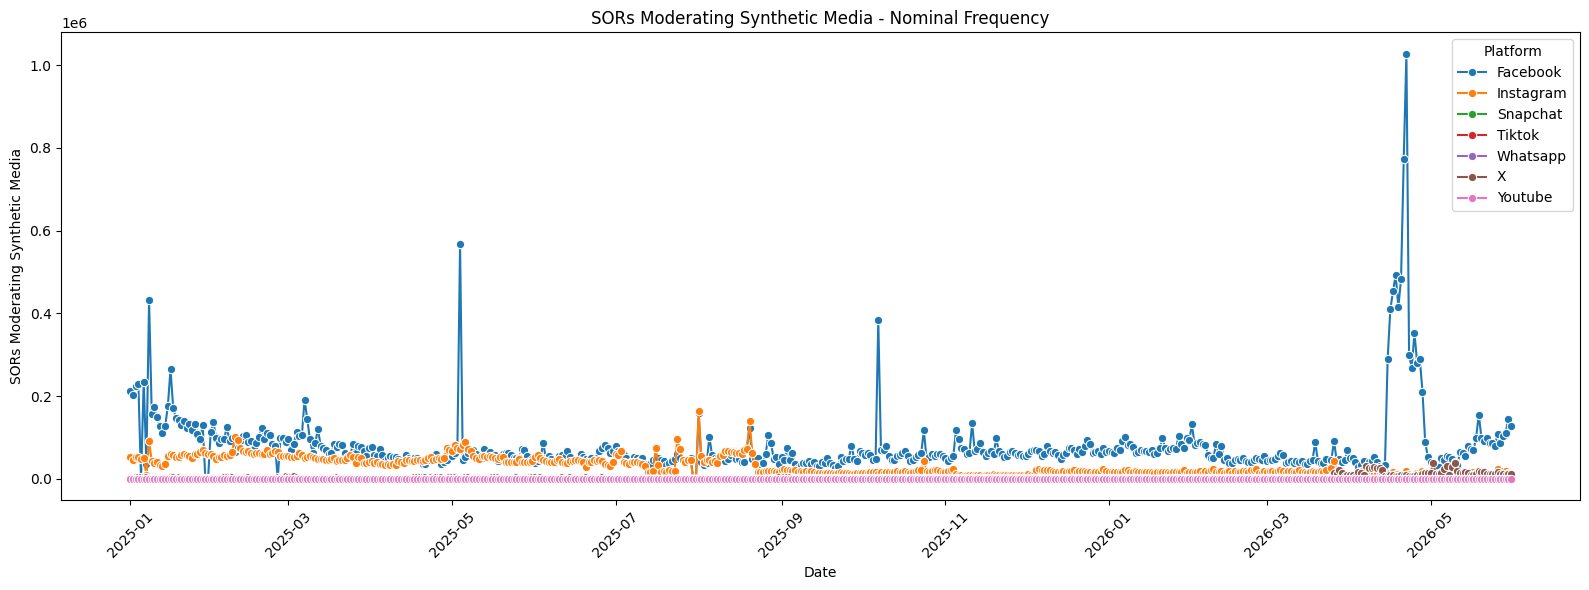

In [72]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Visualisations ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Visualise: Synthetic Media of all Platforms
plt.figure(figsize=(16,6))

sns.lineplot(data = df_cut,
             x = "date",
             y = "content_type_synthetic_media",
             hue = "platform",
             marker = "o")

plt.xlabel("Date")
plt.ylabel("SORs Moderating Synthetic Media")
plt.title("SORs Moderating Synthetic Media - Nominal Frequency")
plt.legend(title = "Platform")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

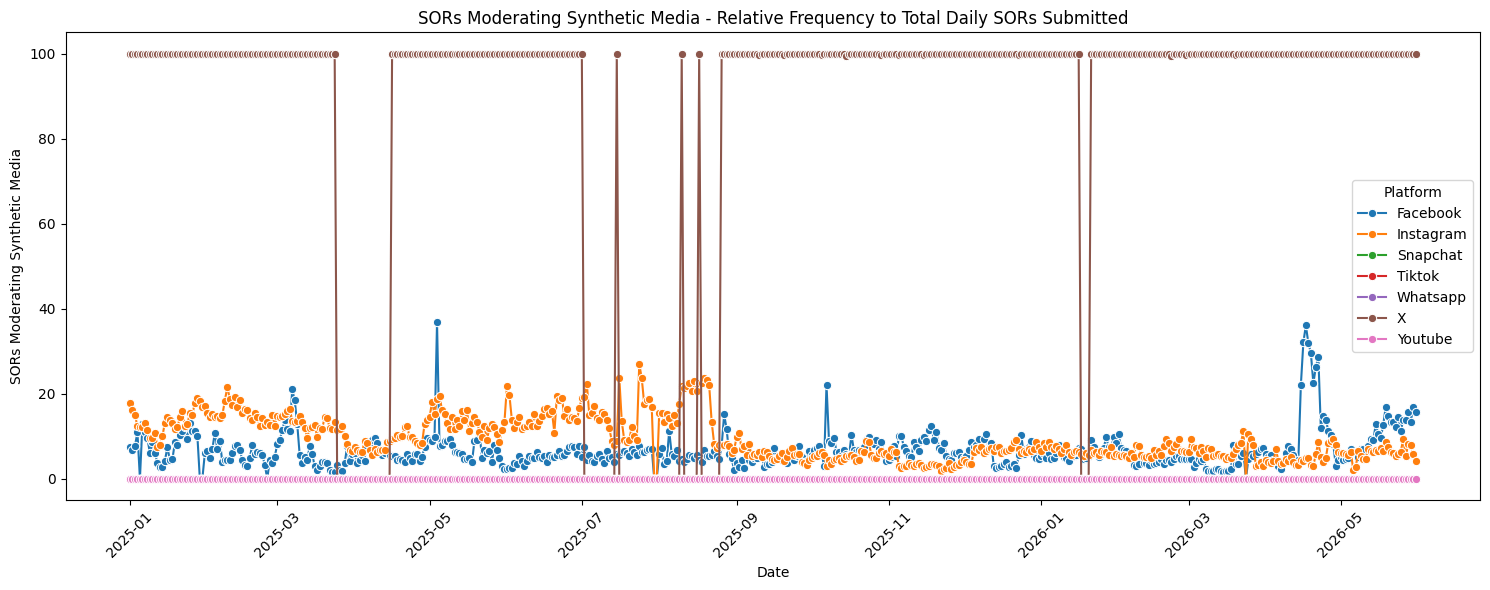

In [65]:
# Visualise Relative to Total Number of SORs Reported
plt.figure(figsize=(15,6))

sns.lineplot(data = df_cut,
             x = "date",
             y = "syn_per_total",
             hue = "platform",
             marker = "o")

plt.xlabel("Date")
plt.ylabel("SORs Moderating Synthetic Media")
plt.title("SORs Moderating Synthetic Media - Relative Frequency to Total Daily SORs Submitted")
plt.legend(title = "Platform")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
df_cut.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3612 entries, 0 to 3611
Data columns (total 14 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   platform                                            3612 non-null   object        
 1   date                                                3612 non-null   datetime64[us]
 2   total_sor_entries                                   3612 non-null   float64       
 3   content_type_image                                  3612 non-null   float64       
 4   content_type_product                                3612 non-null   float64       
 5   content_type_synthetic_media                        3612 non-null   float64       
 6   content_type_text                                   3612 non-null   float64       
 7   content_type_video                                  3612 non-null   float64       
 8   content_

In [20]:
df_cut[df_cut["CONTENT_TYPE_IMAGE,CONTENT_TYPE_TEXT_content_type"] != 0]

,platform,date,total_sor_entries,content_type_image,content_type_product,content_type_synthetic_media,content_type_text,content_type_video,content_type_other,content_type_multiple,"CONTENT_TYPE_IMAGE,CONTENT_TYPE_TEXT_content_type","CONTENT_TYPE_IMAGE,CONTENT_TYPE_VIDEO_content_type","CONTENT_TYPE_VIDEO,CONTENT_TYPE_IMAGE_content_type"
1914,tiktok,2026-01-02,860155.0,54706.0,485.0,0.0,263279.0,465218.0,74515.0,0.0,15.0,2.0,1.0
1915,tiktok,2026-01-03,995005.0,67067.0,302.0,0.0,292623.0,523752.0,109401.0,0.0,20.0,1.0,1.0
1916,tiktok,2026-01-04,1710985.0,95745.0,341.0,0.0,390916.0,883095.0,338102.0,0.0,32.0,0.0,2.0
1917,tiktok,2026-01-05,1345816.0,93298.0,296.0,0.0,354449.0,760436.0,134641.0,0.0,29.0,0.0,1.0
1918,tiktok,2026-01-06,1555984.0,135987.0,713.0,0.0,313174.0,942469.0,159223.0,0.0,18.0,2.0,3.0
1919,tiktok,2026-01-07,1915037.0,101625.0,262.0,0.0,362738.0,1248155.0,199351.0,0.0,8.0,1.0,0.0


In [21]:
df_cut[df_cut["content_type_multiple"] != 0]

,platform,date,total_sor_entries,content_type_image,content_type_product,content_type_synthetic_media,content_type_text,content_type_video,content_type_other,content_type_multiple,"CONTENT_TYPE_IMAGE,CONTENT_TYPE_TEXT_content_type","CONTENT_TYPE_IMAGE,CONTENT_TYPE_VIDEO_content_type","CONTENT_TYPE_VIDEO,CONTENT_TYPE_IMAGE_content_type"
1913,tiktok,2026-01-01,786865.0,45886.0,303.0,0.0,237228.0,410804.0,90835.0,5.0,0.0,0.0,0.0
3461,youtube,2026-01-01,160558.0,0.0,0.0,0.0,0.0,13333.0,147153.0,72.0,0.0,0.0,0.0


In [16]:
print(df.columns.tolist())

['platform', 'date', 'total_sor_entries', 'content_date_earliest', 'content_date_latest', 'automated_detection_no', 'automated_detection_yes', 'automated_decision_partially', 'automated_decision_not_automated', 'content_language_NA', 'source_a16', 'source_voluntary', 'content_type_image', 'content_type_product', 'content_type_synthetic_media', 'content_type_text', 'content_type_video', 'content_type_other', 'data_proection_and_privacy', 'illegal_or_harmful_speech', 'intellectual_prop_infringement', 'protection_of_minors', 'public_security_risk', 'scams_and_fraud', 'self_harm', 'violence', 'pornographic_or_sexual_content', 'scope_of_platform_service', 'illegal_content', 'incompatible_content', 'content_removed', 'content_disabled', 'content_demoted', 'content_labelled', 'content_decision_NA', 'service_decision_NA', 'monetary_account_suspension', 'monetary_decision_NA', 'account_suspended', 'account_terminated', 'account_decision_NA', 'terr_eu_inc_eea', 'terr_eu_ex_eea', 'terr_de', 'terr

In [63]:
df_cut.head(10)

,platform,date,total_sor_entries,content_type_image,content_type_product,content_type_synthetic_media,content_type_text,content_type_video,content_type_other,content_type_multiple,"CONTENT_TYPE_IMAGE,CONTENT_TYPE_TEXT_content_type","CONTENT_TYPE_IMAGE,CONTENT_TYPE_VIDEO_content_type","CONTENT_TYPE_VIDEO,CONTENT_TYPE_IMAGE_content_type",syn_per_total
0,Facebook,2025-01-01,2843732.0,64676.0,13881.0,212808.0,5766.0,46409.0,2500192.0,0.0,0.0,0.0,0.0,7.483406
1,Facebook,2025-01-02,3016407.0,62157.0,16813.0,203433.0,6412.0,48557.0,2679035.0,0.0,0.0,0.0,0.0,6.744216
2,Facebook,2025-01-03,2890417.0,70915.0,25158.0,223850.0,8483.0,49980.0,2512031.0,0.0,0.0,0.0,0.0,7.744557
3,Facebook,2025-01-04,2097347.0,49953.0,32228.0,228918.0,8481.0,67363.0,1710404.0,0.0,0.0,0.0,0.0,10.914646
4,Facebook,2025-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
5,Facebook,2025-01-06,1826593.0,43237.0,29754.0,235187.0,9812.0,35735.0,1472868.0,0.0,0.0,0.0,0.0,12.875720
6,Facebook,2025-01-07,329590.0,6731.0,4364.0,36282.0,1304.0,7218.0,273691.0,0.0,0.0,0.0,0.0,11.008222
7,Facebook,2025-01-08,4539930.0,93863.0,75265.0,431046.0,16055.0,83620.0,3840081.0,0.0,0.0,0.0,0.0,9.494552
8,Facebook,2025-01-09,2613633.0,48568.0,40876.0,157379.0,8642.0,42078.0,2316090.0,0.0,0.0,0.0,0.0,6.021465
9,Facebook,2025-01-10,1993179.0,68200.0,40793.0,174745.0,7153.0,47100.0,1655188.0,0.0,0.0,0.0,0.0,8.767150


In [68]:
df_cut[(df_cut["syn_per_total"] != 0) & (df_cut["platform"] == "X") & (df_cut["syn_per_total"] < 100)]

,platform,date,total_sor_entries,content_type_image,content_type_product,content_type_synthetic_media,content_type_text,content_type_video,content_type_other,content_type_multiple,"CONTENT_TYPE_IMAGE,CONTENT_TYPE_TEXT_content_type","CONTENT_TYPE_IMAGE,CONTENT_TYPE_VIDEO_content_type","CONTENT_TYPE_VIDEO,CONTENT_TYPE_IMAGE_content_type",syn_per_total
2582,X,2025-01-03,3736.0,0.0,0.0,3735.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.973233
2584,X,2025-01-05,3299.0,0.0,0.0,3297.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.939376
2588,X,2025-01-09,2684.0,0.0,0.0,2683.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.962742
2589,X,2025-01-10,2828.0,0.0,0.0,2827.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.964639
2591,X,2025-01-12,3023.0,0.0,0.0,3022.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.966920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3088,X,2026-05-24,11381.0,0.0,0.0,11380.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.991213
3092,X,2026-05-28,12300.0,0.0,0.0,12299.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.991870
3093,X,2026-05-29,8185.0,0.0,0.0,8184.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.987783
3094,X,2026-05-30,11149.0,0.0,0.0,11147.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.982061
